# Radiogenomic Recoverability — Image-Identifiable Genomic Subspaces

This notebook implements the linear–Gaussian model of `main.tex` on a pair of
[`AnnData`](https://anndata.readthedocs.io/) objects:

- **genomics** — a patient × genomics matrix $\mathbf{G}\in\mathbb{R}^{n\times p}$
- **imaging** — a patient × imaging matrix $\mathbf{X}\in\mathbb{R}^{n\times d}$

Set the two `.h5ad` paths in the configuration cell. If they are absent, the
notebook falls back to a **synthetic dataset with known ground truth**, so every
estimate can be checked against the value it is supposed to recover.

The question is not *"does imaging predict gene $j$?"* but *"which low-dimensional
genomic subspaces are image-identifiable?"* — answered by the **recoverability
spectrum** $\{\rho_i^2\}$ and the genomic directions $\{a_i\}$ that achieve it.
All heavy lifting lives in the `rgit` package; the notebook just orchestrates and
visualizes.

## The model in brief

Genomics has a Gaussian prior and imaging is a noisy linear readout of it:

$$G \sim \mathcal{N}(0,\Sigma_G), \qquad X \mid G \sim \mathcal{N}(AG,\ \sigma^2 I_d).$$

Every quantity below is then closed-form (see `main.tex` for derivations):

| quantity | formula | meaning |
|---|---|---|
| Bayes-optimal predictor | $\hat g(x)=\Sigma_{GX}\Sigma_X^{-1}x$ | best possible $E[g\mid x]$ |
| posterior covariance | $\Sigma_{G\mid X}=\Sigma_G-\Sigma_{GX}\Sigma_X^{-1}\Sigma_{XG}$ | hard floor on residual uncertainty |
| recoverability of $a_i$ | $R_i=\rho_i^2$ | $1-$ fraction of variance surviving imaging |
| mutual information | $I(G;X)=-\tfrac12\sum_i\log(1-\rho_i^2)$ | total information budget |

The recoverability directions solve a generalized eigenproblem that **coincides
with canonical correlation analysis** between $\mathbf{G}$ and $\mathbf{X}$, so we
only ever estimate the three second moments $\Sigma_G,\Sigma_X,\Sigma_{GX}$ —
never $A$ or $\sigma^2$ individually.

## 1 · Configuration and imports

In [1]:
import sys
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import anndata as ad
import scipy.sparse as sp
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
from sklearn.model_selection import train_test_split
import scanpy as sc

# --- make the rgit package importable whether or not it is pip-installed ---
REPO_ROOT = Path.cwd().parent.parent if Path.cwd().name == "out" else Path.cwd().parent if Path.cwd().name == "notebooks" else Path.cwd()
if str(REPO_ROOT) not in sys.path:
    sys.path.insert(0, str(REPO_ROOT))

import rgit

In [2]:
# --- paths to the two AnnData objects -------------------------------------
GENOMICS_H5AD = REPO_ROOT / "data" / "tcga_kirc" / "genomics" / "gene_expression.h5ad"
IMAGING_H5AD  = REPO_ROOT / "data" / "tcga_kirc" / "imaging" / "tumor_radiomics.h5ad"
GENOMICS_DATA_TYPE = "variant"  # variant or expression

USE_SYNTHETIC = not (GENOMICS_H5AD.exists() and IMAGING_H5AD.exists())

# --- gene expression filtering -------------------------------------------
EXPRESSION_LAYER        = "unstranded"  # which layer to use as X
MIN_EXPRESSED_PATIENTS  = 3              # minimum patients expressing a gene
DO_CPM_NORMALIZATION    = True                            # whether to convert raw counts to counts-per-million
DO_LOG1P                = True                            # whether to log-transform the expression data after filtering
DO_HVG_SELECTION        = True                            # whether to select highly variable genes after filtering
NUM_BINS                = None               # if >0, binarize expression into this many quantiles

# --- analysis settings ----------------------------------------------------
SEED                    = 0
N_COMPONENTS_MAX        = 12     # upper bound on canonical directions reported
SAMPLES_PER_DIM         = 5      # target ratio n / dim(modality) after reduction
MIN_WORKING_DIM         = 4      # never reduce below this many components
N_FOLDS                 = 5      # cross-validation folds
N_PERM                  = 200    # permutations for the significance test

# Heuristic: CCA-style estimators trivially saturate (rho_i = 1) once the working
# dimension of either modality approaches n; even with shrinkage the in-sample
# spectrum is heavily biased upward when dim is a sizeable fraction of n. We
# therefore cap each modality's working dimension at ~n / SAMPLES_PER_DIM,
# applying PCA on whichever side exceeds that budget.

plt.rcParams.update({"figure.dpi": 110, "axes.grid": True, "grid.alpha": 0.3})
rng = np.random.default_rng(SEED)
print(f"repo root         : {REPO_ROOT}")
print(f"using synthetic   : {USE_SYNTHETIC}")

repo root         : /home/jrich/Desktop/rgit
using synthetic   : False


## 2 · Load the data

`load_data()` reads the two `.h5ad` files when they exist. Otherwise it draws a
synthetic dataset from the probabilistic-CCA generative model
($Z\in\mathbb{R}^k$ shared latent, modality-private anisotropic noise) and wraps
it in `AnnData` objects with the same interface — including a deliberately
shuffled patient order on the imaging side, so the alignment step is exercised.
When synthetic, `truth` carries the generative parameters for later validation.

In [3]:
GENOMICS_DATA_TYPE = "gene_expression" if "gene_expression" in str(GENOMICS_H5AD) else GENOMICS_DATA_TYPE
if GENOMICS_DATA_TYPE == "variant":
    DO_CPM_NORMALIZATION = False
    DO_LOG1P = False
    DO_HVG_SELECTION = False

def load_data_real():
    gen = ad.read_h5ad(GENOMICS_H5AD)
    img = ad.read_h5ad(IMAGING_H5AD)

    # keep only patients with both genomics and imaging
    common_patients = gen.obs_names.intersection(img.obs_names)

    gen = gen[common_patients].copy()
    img = img[common_patients].copy()

    # select expression layer
    if EXPRESSION_LAYER in gen.layers:
        X = gen.layers[EXPRESSION_LAYER]
    else:
        X = gen.X

    # convert sparse -> dense once
    if sp.issparse(X):
        X = X.toarray()
    else:
        X = np.asarray(X)

    # ensure numeric dtype
    X = X.astype(np.float32)

    # # commented out because I should not bin before PCA
    # # optional quantile binning
    # if NUM_BINS > 0:
    #     gen.layers["non_binned"] = X.copy()  # preserve raw expression before binning
    #     X_binned = np.zeros_like(X, dtype=np.int8)

    #     for i in range(X.shape[1]):
    #         col = X[:, i]

    #         # handle constant columns
    #         if np.all(col == col[0]):
    #             X_binned[:, i] = 0
    #             continue

    #         try:
    #             binned = pd.qcut(
    #                 col,
    #                 q=NUM_BINS,
    #                 labels=False,
    #                 duplicates="drop",
    #             )

    #             # qcut may return NaNs
    #             X_binned[:, i] = np.nan_to_num(
    #                 np.asarray(binned),
    #                 nan=0,
    #             ).astype(np.int8)

    #         except ValueError:
    #             # fallback for pathological columns
    #             X_binned[:, i] = 0

    #     X = X_binned

    # assign processed matrix back
    gen.X = X

    # filter genes expressed in >= MIN_EXPRESSED_PATIENTS
    if MIN_EXPRESSED_PATIENTS > 0:
        expressed = (X > 0).sum(axis=0)
        expressed = np.asarray(expressed).ravel()
        keep = expressed >= MIN_EXPRESSED_PATIENTS
        gen = gen[:, keep].copy()
    
    if DO_CPM_NORMALIZATION:
        sc.pp.normalize_total(gen, target_sum=1e6, inplace=True)
    
    if DO_LOG1P:
        # print(gen.X.min())
        # print(gen.X.max())
        # print(np.percentile(gen.X, [50, 90, 99]))
        gen.X = np.log1p(gen.X)
    
    if DO_HVG_SELECTION:
        sc.pp.highly_variable_genes(gen, n_top_genes=2000, subset=True)

    print(f"loaded genomics {gen.shape} and imaging {img.shape} from disk")

    return gen, img, None

def load_data():
    '''Return (genomics_adata, imaging_adata, truth_or_None).'''
    if not USE_SYNTHETIC:
        return load_data_real()

    # ---- synthetic fallback with known ground truth ----
    G, X, truth = rgit.make_synthetic_radiogenomics(
        n=800, p=80, d=40, k=6, random_state=SEED,
    )
    patients = np.array([f"P{i:04d}" for i in range(G.shape[0])])
    genes    = [f"GENE{i:04d}" for i in range(G.shape[1])]
    feats    = [f"radiomic_{i:03d}" for i in range(X.shape[1])]

    gen = ad.AnnData(
        X=G, obs=pd.DataFrame(index=patients),
        var=pd.DataFrame(index=genes),
    )
    # shuffle imaging patient order to make alignment non-trivial
    order = rng.permutation(G.shape[0])
    img = ad.AnnData(
        X=X[order], obs=pd.DataFrame(index=patients[order]),
        var=pd.DataFrame(index=feats),
    )
    print(f"synthetic genomics {gen.shape} and imaging {img.shape} "
          f"(true shared rank k={truth['k']})")

    gen.write_h5ad(str(GENOMICS_H5AD).replace(".h5ad", "_synthetic.h5ad"))
    img.write_h5ad(str(IMAGING_H5AD).replace(".h5ad", "_synthetic.h5ad"))
    
    return gen, img, truth


genomics_adata, imaging_adata, truth = load_data()

loaded genomics (190, 2000) and imaging (190, 107) from disk


In [4]:
# if gene_name in genomics_adata.var.columns, then pop out index and set it to gene_name
if "gene_name" in genomics_adata.var.columns:
    genomics_adata.var.reset_index(inplace=True)
    genomics_adata.var_names = genomics_adata.var["gene_name"].astype(str)
    genomics_adata.var.drop(columns=["gene_name"], inplace=True)

In [ ]:
# print the 10 features in gen adata object with the highest total counts (ie sum across all rows)
genes_mutation_counts = genomics_adata.X.sum(axis=0)
genes_mutation_counts = np.asarray(genes_mutation_counts).flatten()
genes_mutation_counts = pd.Series(genes_mutation_counts, index=genomics_adata.var_names)
genes_mutation_counts = genes_mutation_counts.sort_values(ascending=False)
print(genes_mutation_counts.head(10))

gene_name
COL1A2      1227.382812
COL1A1      1215.133179
COL3A1      1192.993652
CXCL14      1096.147461
PDK4        1084.555542
IGKC        1076.313965
COL6A1      1073.126221
IGHG1       1063.591064
RPS28       1014.940002
SERPINE1    1014.653259
dtype: float32


## 3 · Align patients and preprocess

Steps:

1. **Align** on the intersection of `obs_names` so both matrices are
   patient-aligned, row for row.
2. **Standardize** each feature (z-score) within each modality.
3. **Optionally PCA-reduce genomics** when $p$ is large — the manuscript's rank
   limit (Prop. 6) says imaging can only expose a low-dimensional projection of
   genomics, so little is lost provided the retained dimension exceeds the
   recoverable rank. We keep the `PCA` object to back-project genomic directions
   to gene space for interpretation.

In [6]:
# 1 · align on shared patients --------------------------------------------
shared = genomics_adata.obs_names.intersection(imaging_adata.obs_names)
shared = pd.Index(sorted(shared))
genomics_adata = genomics_adata[shared].copy()
imaging_adata  = imaging_adata[shared].copy()
assert (genomics_adata.obs_names == imaging_adata.obs_names).all()
n_samples = len(shared)
print(f"{n_samples} patients shared between modalities")

# 2 · standardize each modality -------------------------------------------
G_raw = rgit.to_dense(genomics_adata.X)
X_raw = rgit.to_dense(imaging_adata.X)
G_std = StandardScaler().fit_transform(G_raw)
X_std = StandardScaler().fit_transform(X_raw)

# 3 · adaptive dimension reduction ----------------------------------------
# Target working dim per modality: n / SAMPLES_PER_DIM, but no fewer than
# MIN_WORKING_DIM and no more than the modality\'s native dimension or n-1.
def _reduce(M, name):
    p_native = M.shape[1]
    budget   = max(MIN_WORKING_DIM, n_samples // SAMPLES_PER_DIM)
    target   = min(p_native, n_samples - 1, budget)
    if target < p_native:
        pca = PCA(n_components=target, random_state=SEED).fit(M)
        return pca.transform(M), pca, f"{target} {name} PCs"
    return M, None, f"standardized {name} features"

G_model, pca_g, gen_space = _reduce(G_std, "genomic")
X_model, pca_x, img_space = _reduce(X_std, "imaging")

# cap N_COMPONENTS at the actual working rank we can support
N_COMPONENTS = max(1, min(N_COMPONENTS_MAX, G_model.shape[1], X_model.shape[1],
                          n_samples - 1))

gene_names = np.asarray(genomics_adata.var_names)
feat_names = np.asarray(imaging_adata.var_names)

def to_gene_loadings(dirs):
    '''Map directions in the modeling space back to (standardized) gene space.'''
    return pca_g.components_.T @ dirs if pca_g is not None else dirs

def to_feature_loadings(dirs):
    '''Map directions in the modeling space back to (standardized) imaging-feature space.'''
    return pca_x.components_.T @ dirs if pca_x is not None else dirs

# regime warning ---------------------------------------------------------
total_dim = G_model.shape[1] + X_model.shape[1]
if total_dim >= n_samples:
    print("WARNING: dim(G) + dim(X) >= n — in-sample CCA will saturate at "
          "rho_i = 1 by geometry alone. Trust the cross-validated spectrum "
          "and permutation test, not the in-sample numbers below.")
elif total_dim > n_samples // 2:
    print("NOTE: dim(G) + dim(X) > n/2 — in-sample canonical correlations are "
          "noticeably biased upward; rely on cross-validation for honest values.")

print(f"genomics modeled in : {gen_space}  -> G {G_model.shape}")
print(f"imaging  modeled in : {img_space}  -> X {X_model.shape}")
print(f"N_COMPONENTS        : {N_COMPONENTS} (capped by working dims and n-1)")


190 patients shared between modalities
genomics modeled in : 38 genomic PCs  -> G (190, 38)
imaging  modeled in : 38 imaging PCs  -> X (190, 38)
N_COMPONENTS        : 12 (capped by working dims and n-1)


/home/jrich/.conda/envs/rgit/lib/python3.10/site-packages/anndata/_core/anndata.py:1758: UserWarning: Variable names are not unique. To make them unique, call `.var_names_make_unique`.
  utils.warn_names_duplicates("var")


## 4 · Fit the recoverability model

`rgit.fit_recoverability` forms regularized covariances $\hat\Sigma_G,
\hat\Sigma_X,\hat\Sigma_{GX}$ (Ledoit–Wolf shrinkage by default), builds the
whitened transfer operator $M=\hat\Sigma_G^{-1/2}\hat\Sigma_{GX}\hat\Sigma_X^{-1/2}$,
and reads the canonical correlations $\rho_i$ off its SVD. This *is* regularized
CCA — the recoverability program and CCA are the same computation.

In [7]:
fit = rgit.fit_recoverability(G_model, X_model, n_components=N_COMPONENTS)

spectrum = pd.DataFrame({
    "component":       np.arange(1, fit.n_components + 1),
    "rho":             fit.rho,
    "recoverability":  fit.recoverability,   # R_i = rho_i^2  (in-sample)
})
print(f"mutual information  I(G;X) = {fit.mutual_information():.2f} nats "
      f"({fit.mutual_information() / np.log(2):.2f} bits)")
spectrum.round(4)

mutual information  I(G;X) = 3.29 nats (4.75 bits)


,component,rho,recoverability
0,1,0.9957,0.9915
1,2,0.6292,0.3958
2,3,0.5166,0.2669
3,4,0.4959,0.2459
4,5,0.4225,0.1785
5,6,0.3574,0.1278
6,7,0.3252,0.1057
7,8,0.2816,0.0793
8,9,0.2430,0.0590
9,10,0.2239,0.0501


## 5 · Imaging covariance decomposition

The model splits imaging covariance additively,
$\Sigma_X = \underbrace{A\Sigma_G A^\top}_{\text{genomics-driven}} + \underbrace{\sigma^2 I_d}_{\text{irreducible}}$.
`rgit.imaging_variance_explained` reports the genomics-driven share,
$\operatorname{tr}(\Sigma_{XG}\Sigma_G^{-1}\Sigma_{GX})/\operatorname{tr}(\Sigma_X)$.

fraction of imaging variance attributable to genomics
  in-sample (biased when dim ~ n) : 0.174
  cross-validated proxy           : 0.009
irreducible (genomics-independent) share (in-sample): 0.826


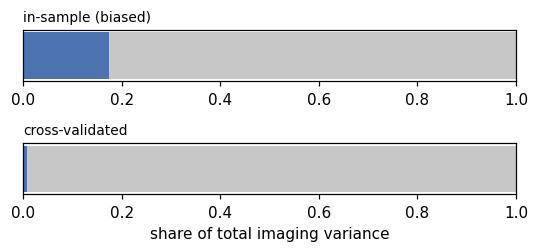

In [8]:
frac, signal_cov = rgit.imaging_variance_explained(fit)

# In-sample frac is biased upward when dim is large relative to n (it counts
# every direction in the genomic span, real or noise). A more honest estimate
# weights only the cross-validated recoverability into the imaging eigenbasis:
# share_signal ~ sum_i R_i^cv * lambda_i(Sx_along_canonical_axis) / tr(Sx).
# As a simple, dimension-aware proxy we report:
#   frac_cv = sum_i R_i^cv  /  min(dim(G), dim(X))
# i.e. the fraction of *recoverable* canonical directions that actually carry
# out-of-sample signal. This is shown alongside the raw in-sample number.

cv_for_frac = rgit.cross_validated_recoverability(
    G_model, X_model, n_components=N_COMPONENTS,
    n_folds=N_FOLDS, random_state=SEED,
).mean(axis=0)
frac_cv = float(np.clip(cv_for_frac, 0, 1).sum()
                / max(1, min(G_model.shape[1], X_model.shape[1])))

print(f"fraction of imaging variance attributable to genomics")
print(f"  in-sample (biased when dim ~ n) : {frac:.3f}")
print(f"  cross-validated proxy           : {frac_cv:.3f}")
print(f"irreducible (genomics-independent) share (in-sample): {1 - frac:.3f}")

fig, axes = plt.subplots(2, 1, figsize=(5, 2.4))
for ax, value, title in [(axes[0], frac,    "in-sample (biased)"),
                         (axes[1], frac_cv, "cross-validated")]:
    ax.barh([0], [value],     color="#4C72B0")
    ax.barh([0], [1 - value], left=[value], color="#C7C7C7")
    ax.set_xlim(0, 1); ax.set_yticks([])
    ax.set_title(title, fontsize=9, loc="left")
    ax.grid(False)
axes[1].set_xlabel("share of total imaging variance")
plt.tight_layout(); plt.show()


## 6 · The recoverability spectrum

Each canonical direction $a_i$ has recoverability $R_i=\rho_i^2\in[0,1]$:
$R_i=0$ means imaging carries nothing about that genomic direction, $R_i=1$ means
it is pinned down exactly. The number of appreciably non-zero $R_i$ is the
**dimension of the image-identifiable genomic subspace**.

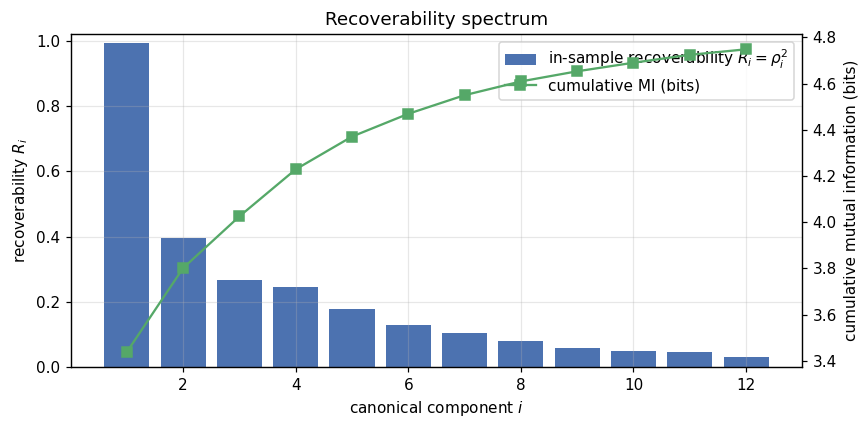

In [9]:
fig, ax1 = plt.subplots(figsize=(8, 4))
comps = spectrum["component"]
ax1.bar(comps, spectrum["recoverability"], color="#4C72B0",
        label="in-sample recoverability $R_i=\\rho_i^2$")
if truth is not None:
    rho_true, R_true = rgit.true_recoverability(truth)
    ax1.plot(np.arange(1, min(len(R_true), N_COMPONENTS) + 1),
             R_true[:N_COMPONENTS], "o--", color="#C44E52",
             label="ground-truth $R_i$")
ax1.set_xlabel("canonical component $i$")
ax1.set_ylabel("recoverability $R_i$")
ax1.set_ylim(0, 1.02)

ax2 = ax1.twinx()
ax2.plot(comps, np.cumsum(-0.5 * np.log1p(-fit.rho ** 2)) / np.log(2),
         "s-", color="#55A868", label="cumulative MI (bits)")
ax2.set_ylabel("cumulative mutual information (bits)")
ax2.grid(False)
lines = ax1.get_legend_handles_labels()[0] + ax2.get_legend_handles_labels()[0]
labs  = ax1.get_legend_handles_labels()[1] + ax2.get_legend_handles_labels()[1]
ax1.legend(lines, labs, loc="upper right", frameon=True)
ax1.set_title("Recoverability spectrum")
plt.tight_layout(); plt.show()

## 7 · Mutual information budget

$I(G;X)=\sum_i\tfrac12\log(1+\mathrm{SNR}_i)$ — each image-visible genomic
direction contributes $\tfrac12\log(1/(1-\rho_i^2))$ nats. Directions with low
signal-to-noise add almost nothing, regardless of how many genes load on them.

total I(G;X)      : 3.291 nats / 4.749 bits
top component     : 2.383 nats
share in top 6 comps: 94.1%


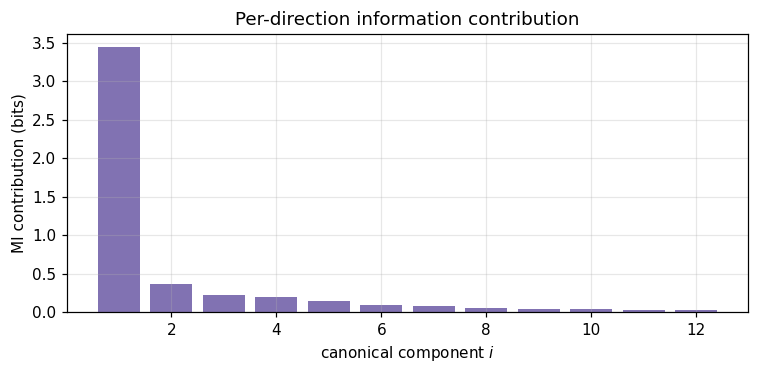

In [10]:
mi_per = -0.5 * np.log1p(-fit.rho ** 2)            # nats per component
print(f"total I(G;X)      : {mi_per.sum():.3f} nats / {mi_per.sum()/np.log(2):.3f} bits")
print(f"top component     : {mi_per[0]:.3f} nats")
print(f"share in top {min(6, fit.n_components)} comps: "
      f"{mi_per[:6].sum() / mi_per.sum():.1%}")

fig, ax = plt.subplots(figsize=(7, 3.5))
ax.bar(spectrum["component"], mi_per / np.log(2), color="#8172B2")
ax.set_xlabel("canonical component $i$")
ax.set_ylabel("MI contribution (bits)")
ax.set_title("Per-direction information contribution")
plt.tight_layout(); plt.show()

## 8 · Bayes-optimal predictor and the posterior floor

`rgit.posterior` returns the optimal linear map $B$ ($\,\hat g(x)=Bx\,$) and the
posterior covariance $\Sigma_{G\mid X}$ — the hard floor on residual genomic
uncertainty that **no estimator can beat**. We hold out a test split, predict
genomics from imaging, and check the leading canonical genomic score.

held-out R^2, leading genomic direction : -2.100
median posterior variance retained      : 0.975


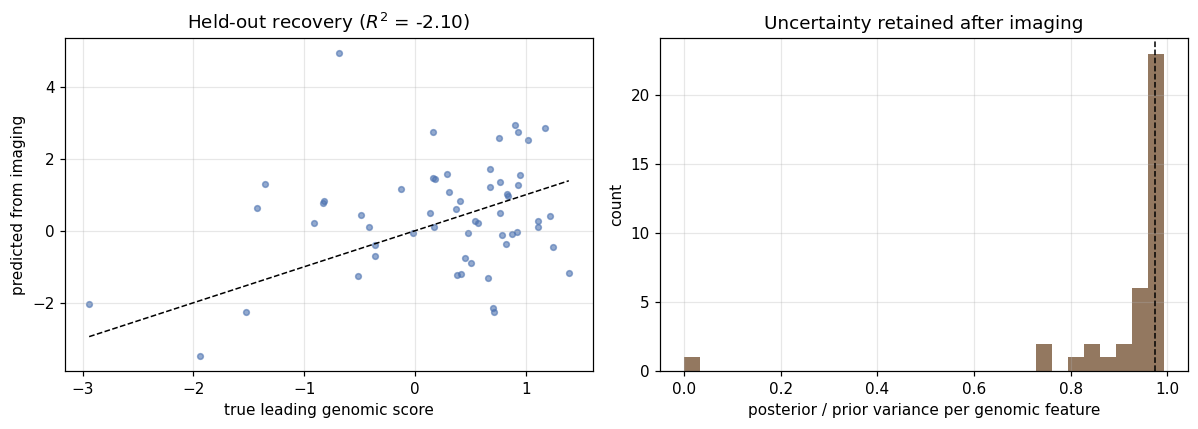

In [11]:
idx = np.arange(G_model.shape[0])
tr, te = train_test_split(idx, test_size=0.3, random_state=SEED)

fit_tr = rgit.fit_recoverability(G_model[tr], X_model[tr], n_components=N_COMPONENTS)
B, Sgcx = rgit.posterior(fit_tr)

# predict genomics from imaging on the held-out split
G_te_c   = G_model[te] - fit_tr.g_mean
X_te_c   = X_model[te] - fit_tr.x_mean
G_te_hat = X_te_c @ B.T

a1            = fit_tr.genomic_dirs[:, 0]               # leading genomic direction
score_true    = G_te_c   @ a1
score_pred    = G_te_hat @ a1
ss_res        = np.sum((score_true - score_pred) ** 2)
ss_tot        = np.sum((score_true - score_true.mean()) ** 2)
r2_heldout    = 1 - ss_res / ss_tot

# variance retained after observing imaging, per genomic feature
var_ratio = np.clip(np.diag(Sgcx) / np.diag(fit_tr.Sg), 0, 1)
print(f"held-out R^2, leading genomic direction : {r2_heldout:.3f}")
print(f"median posterior variance retained      : {np.median(var_ratio):.3f}")

fig, axes = plt.subplots(1, 2, figsize=(11, 4))
axes[0].scatter(score_true, score_pred, s=14, alpha=0.6, color="#4C72B0")
lim = [score_true.min(), score_true.max()]
axes[0].plot(lim, lim, "k--", lw=1)
axes[0].set_xlabel("true leading genomic score")
axes[0].set_ylabel("predicted from imaging")
axes[0].set_title(f"Held-out recovery ($R^2$ = {r2_heldout:.2f})")

axes[1].hist(var_ratio, bins=30, color="#937860")
axes[1].axvline(np.median(var_ratio), color="k", ls="--", lw=1)
axes[1].set_xlabel("posterior / prior variance per genomic feature")
axes[1].set_ylabel("count")
axes[1].set_title("Uncertainty retained after imaging")
plt.tight_layout(); plt.show()

## 9 · Image-identifiable genomic directions

The recoverability eigenproblem returns the genomic directions $a_i$ imaging
sees best. Reading their loadings back onto genes answers *which biology is
image-identifiable* — leading directions typically align with coarse, spatially
expressed programs rather than individual transcripts.

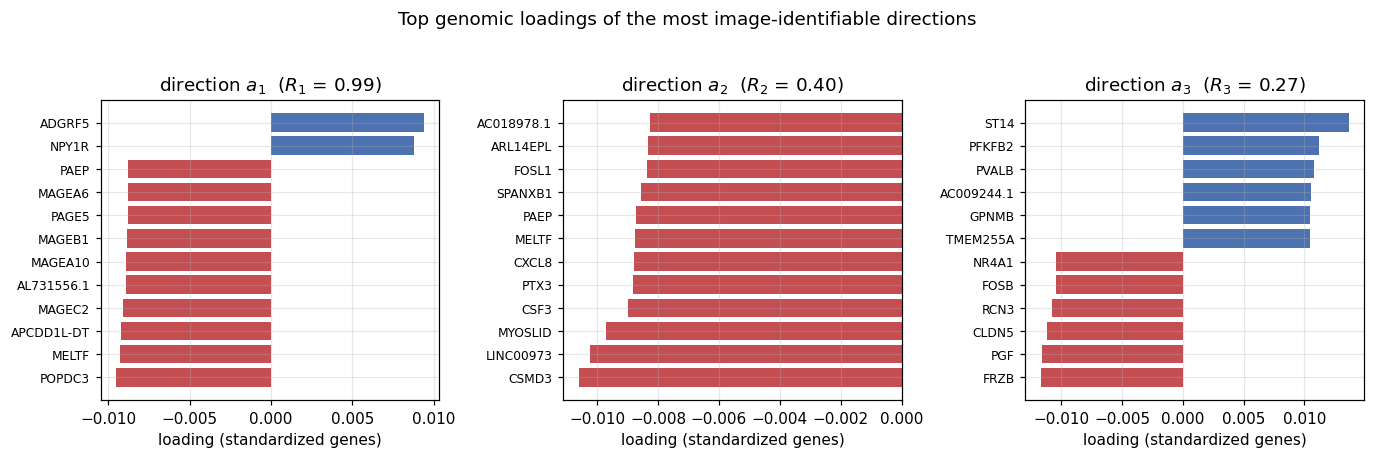

In [12]:
gene_dirs = to_gene_loadings(fit.genomic_dirs)        # (n_genes, n_components)
n_show = min(3, fit.n_components)
top_k  = 12

fig, axes = plt.subplots(1, n_show, figsize=(4.2 * n_show, 4), sharey=False)
axes = np.atleast_1d(axes)
for i in range(n_show):
    load = gene_dirs[:, i]
    order = np.argsort(-np.abs(load))[:top_k]
    order = order[np.argsort(load[order])]
    k = len(order)
    colors = ["#C44E52" if v < 0 else "#4C72B0" for v in load[order]]
    axes[i].barh(np.arange(k), load[order], color=colors)
    axes[i].set_yticks(np.arange(k))
    axes[i].set_yticklabels(gene_names[order], fontsize=8)
    axes[i].set_title(f"direction $a_{{{i+1}}}$  ($R_{{{i+1}}}$ = {fit.recoverability[i]:.2f})")
    axes[i].set_xlabel("loading (standardized genes)")
fig.suptitle("Top genomic loadings of the most image-identifiable directions", y=1.03)
plt.tight_layout(); plt.show()

## 9b · Non-linear validation — per-gene predictability

The recoverability theory makes a sharp, falsifiable prediction: genes that
load strongly on highly recoverable directions should be predictable from
imaging, while genes orthogonal to the image-identifiable subspace should
not be — and a flexible non-linear model should not substantially exceed
the linear Bayes-optimal ceiling. We pick a handful of high- vs
low-recoverability mutated genes (per-gene posterior-variance reduction
$1 - \Sigma_{G\mid X,\,jj} / \Sigma_{G,\,jj}$), train an $L_2$ logistic
regression and a small random forest to predict each gene's mutation
status from imaging, and compare 5-fold cross-validated AUC. A clean
AUC gap between the two groups corroborates the spectrum; non-linear
models matching but not exceeding the linear ceiling corroborates the
linear–Gaussian model itself.

       gene  mut_freq  R_linear            group  AUC_LR  AUC_RF
 AC006348.1     0.537     0.483     identifiable   0.456   0.512
 AC012103.1     0.453     0.483     identifiable   0.467   0.503
   PABPN1P2     0.674     0.482     identifiable   0.517   0.498
 AC097714.1     0.337     0.481     identifiable   0.614   0.567
 AC092757.1     0.442     0.476     identifiable   0.661   0.655
      PAGE4     0.237     0.009 non-identifiable   0.427   0.417
IGKV1OR2-11     0.384     0.009 non-identifiable   0.550   0.456
 AL354863.1     0.526     0.010 non-identifiable   0.555   0.538
   IGHV3-38     0.700     0.010 non-identifiable   0.533   0.459
      REG1B     0.768     0.011 non-identifiable   0.578   0.532

mean AUC by group:
                  AUC_LR  AUC_RF
group                           
identifiable       0.543   0.547
non-identifiable   0.529   0.480


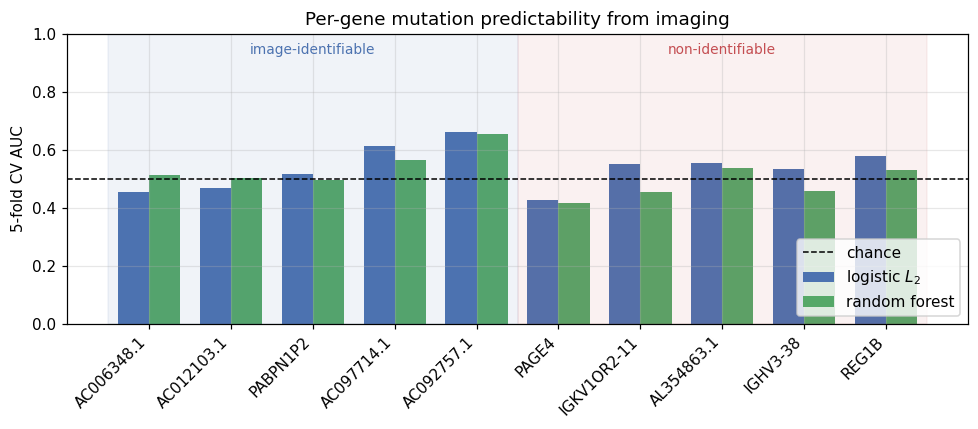

In [13]:
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import StratifiedKFold
from sklearn.metrics import roc_auc_score
from sklearn.preprocessing import StandardScaler as _SS

# --- per-gene recoverability in standardized gene space ------------------
_, Sgcx_full = rgit.posterior(fit)
if pca_g is not None:
    W = pca_g.components_                                   # (n_pc, n_genes)
    post_var_gene  = np.einsum("ig,ij,jg->g", W, Sgcx_full, W)
    prior_var_gene = np.einsum("ig,ij,jg->g", W, fit.Sg,    W)
else:
    post_var_gene, prior_var_gene = np.diag(Sgcx_full), np.diag(fit.Sg)
gene_recov = np.clip(1.0 - post_var_gene / np.maximum(prior_var_gene, 1e-12), 0, 1)

# --- pick eligible mutated genes ----------------------------------------
G_bin    = (G_raw > 0).astype(int)
mut_freq = G_bin.mean(axis=0)
MUT_LO, MUT_HI = 0.05, 0.95
eligible = np.where((mut_freq >= MUT_LO) & (mut_freq <= MUT_HI))[0]
if len(eligible) < 4:
    print(f"only {len(eligible)} genes mutated in [{MUT_LO:.0%}, {MUT_HI:.0%}] of "
          "patients - skipping per-gene validation.")
else:
    order = eligible[np.argsort(gene_recov[eligible])]
    n_pick     = min(5, len(eligible) // 2)
    low_genes  = order[:n_pick]
    high_genes = order[-n_pick:][::-1]

    def _cv_auc(y, x, n_folds=5):
        skf = StratifiedKFold(n_splits=n_folds, shuffle=True, random_state=SEED)
        a_lr, a_rf = [], []
        for tr, te in skf.split(x, y):
            if len(np.unique(y[te])) < 2:
                continue
            sc = _SS().fit(x[tr])
            lr = LogisticRegression(C=1.0, max_iter=2000,
                                    class_weight="balanced")
            lr.fit(sc.transform(x[tr]), y[tr])
            a_lr.append(roc_auc_score(y[te],
                lr.predict_proba(sc.transform(x[te]))[:, 1]))
            rf = RandomForestClassifier(n_estimators=300, max_depth=4,
                                        min_samples_leaf=3, random_state=SEED,
                                        class_weight="balanced", n_jobs=-1)
            rf.fit(x[tr], y[tr])
            a_rf.append(roc_auc_score(y[te], rf.predict_proba(x[te])[:, 1]))
        return (np.mean(a_lr) if a_lr else np.nan,
                np.mean(a_rf) if a_rf else np.nan)

    rows = []
    for j in np.concatenate([high_genes, low_genes]):
        auc_lr, auc_rf = _cv_auc(G_bin[:, j], X_model)
        rows.append({
            "gene":     gene_names[j],
            "mut_freq": mut_freq[j],
            "R_linear": gene_recov[j],
            "group":    "identifiable" if j in high_genes else "non-identifiable",
            "AUC_LR":   auc_lr,
            "AUC_RF":   auc_rf,
        })
    gene_table = pd.DataFrame(rows)
    print(gene_table.round(3).to_string(index=False))

    grp = gene_table.groupby("group")[["AUC_LR", "AUC_RF"]].mean().round(3)
    print("\nmean AUC by group:"); print(grp)

    fig, ax = plt.subplots(figsize=(9, 4))
    xp, w = np.arange(len(gene_table)), 0.38
    ax.bar(xp - w/2, gene_table["AUC_LR"], w, label="logistic $L_2$", color="#4C72B0")
    ax.bar(xp + w/2, gene_table["AUC_RF"], w, label="random forest",  color="#55A868")
    ax.axhline(0.5, color="k", ls="--", lw=1, label="chance")
    ax.set_xticks(xp); ax.set_xticklabels(gene_table["gene"], rotation=45, ha="right")
    ax.set_ylabel("5-fold CV AUC"); ax.set_ylim(0, 1)
    nh = len(high_genes)
    ax.axvspan(-0.5,        nh - 0.5,        alpha=0.08, color="#4C72B0")
    ax.axvspan(nh - 0.5,    len(gene_table)-0.5, alpha=0.08, color="#C44E52")
    ax.text((nh-1)/2,                   0.97, "image-identifiable",
            ha="center", va="top", fontsize=9, color="#4C72B0")
    ax.text((nh + len(gene_table)-1)/2, 0.97, "non-identifiable",
            ha="center", va="top", fontsize=9, color="#C44E52")
    ax.set_title("Per-gene mutation predictability from imaging")
    ax.legend(loc="lower right"); plt.tight_layout(); plt.show()

## 10 · Honest recoverability — cross-validation

In-sample $\rho_i^2$ is biased upward. `rgit.cross_validated_recoverability`
estimates the canonical directions on each training fold and reports the
**out-of-sample** squared correlation of the projected scores. The gap to the
in-sample curve is the overfitting.

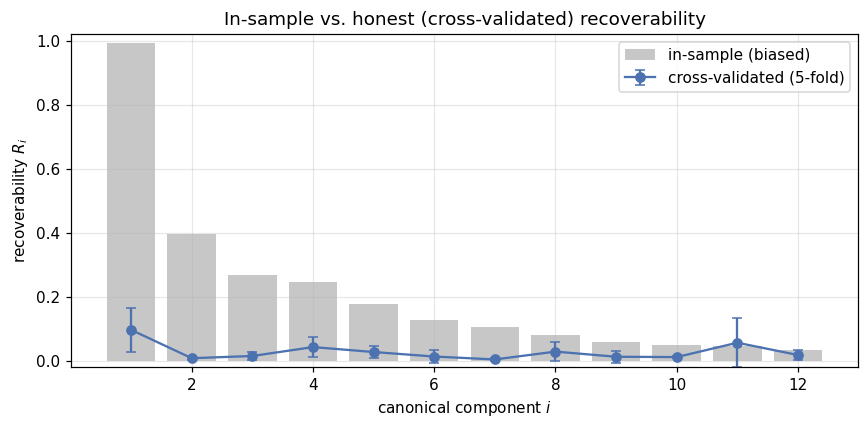

cross-validated recoverability per component:
[0.097 0.008 0.015 0.043 0.027 0.013 0.004 0.029 0.013 0.012 0.057 0.018]


In [14]:
cv = rgit.cross_validated_recoverability(
    G_model, X_model, n_components=N_COMPONENTS,
    n_folds=N_FOLDS, random_state=SEED,
)
cv_mean, cv_std = cv.mean(axis=0), cv.std(axis=0)
comps = spectrum["component"]

fig, ax = plt.subplots(figsize=(8, 4))
ax.bar(comps, fit.recoverability, color="#C7C7C7", label="in-sample (biased)")
ax.errorbar(comps, cv_mean, yerr=cv_std, fmt="o-", color="#4C72B0",
            capsize=3, label=f"cross-validated ({N_FOLDS}-fold)")
if truth is not None:
    _, R_true = rgit.true_recoverability(truth)
    ax.plot(np.arange(1, min(len(R_true), N_COMPONENTS) + 1),
            R_true[:N_COMPONENTS], "x--", color="#C44E52", label="ground truth")
ax.set_xlabel("canonical component $i$")
ax.set_ylabel("recoverability $R_i$")
ax.set_ylim(-0.02, 1.02)
ax.set_title("In-sample vs. honest (cross-validated) recoverability")
ax.legend(); plt.tight_layout(); plt.show()

print("cross-validated recoverability per component:")
print(np.array2string(cv_mean, precision=3, suppress_small=True))

## 11 · Permutation test

Permuting patient labels of one modality destroys any real association. The
permutation distribution of the leading canonical correlation gives a null
against which the observed value is tested — does *any* genomic direction beat
chance?

component 1: rho = 0.996   permutation p = 0.4776
component 2: rho = 0.629   permutation p = 0.4328
component 3: rho = 0.517   permutation p = 0.3433


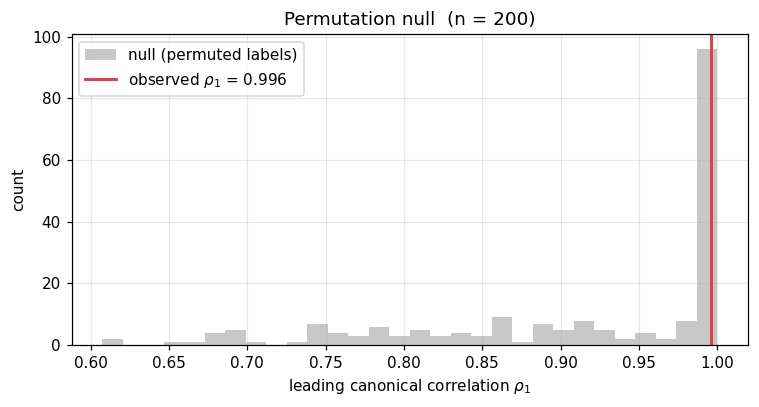

In [15]:
observed, null, pvalues = rgit.permutation_test(
    G_model, X_model, n_components=min(3, N_COMPONENTS),
    n_perm=N_PERM, random_state=SEED,
)
for i, (o, p) in enumerate(zip(observed, pvalues), start=1):
    print(f"component {i}: rho = {o:.3f}   permutation p = {p:.4f}")

fig, ax = plt.subplots(figsize=(7, 3.8))
ax.hist(null[:, 0], bins=30, color="#C7C7C7", label="null (permuted labels)")
ax.axvline(observed[0], color="#C44E52", lw=2,
           label=f"observed $\\rho_1$ = {observed[0]:.3f}")
ax.set_xlabel("leading canonical correlation $\\rho_1$")
ax.set_ylabel("count")
ax.set_title(f"Permutation null  (n = {N_PERM})")
ax.legend(); plt.tight_layout(); plt.show()

## 12 · Validation against ground truth

Run only on synthetic data, where the generative parameters are known. We
compare the estimated recoverability spectrum to the closed-form truth, and
measure how well the estimated image-identifiable subspace aligns with the true
shared subspace via the cosines of the principal angles.

In [16]:
if truth is None:
    print("Real data loaded — no ground truth available; skipping validation.")
else:
    rho_true, R_true = rgit.true_recoverability(truth)
    k = truth["k"]

    # estimated subspace vs. true shared genomic subspace
    est_dirs  = to_gene_loadings(fit.genomic_dirs[:, :k])   # (n_genes, k)
    cos_ang   = rgit.subspace_alignment(est_dirs, truth["Wg"])

    print(f"true shared rank k                 : {k}")
    print(f"true   R (first {k+2})            : "
          f"{np.array2string(R_true[:k+2], precision=3, suppress_small=True)}")
    print(f"CV     R (first {k+2})            : "
          f"{np.array2string(cv_mean[:k+2], precision=3, suppress_small=True)}")
    print(f"subspace alignment (cos angles)    : "
          f"{np.array2string(cos_ang, precision=3)}")
    print(f"mean alignment over true subspace  : {cos_ang.mean():.3f}")

    fig, axes = plt.subplots(1, 2, figsize=(11, 4))
    axes[0].plot(np.arange(1, k + 3), R_true[:k + 2], "o--",
                 color="#C44E52", label="ground truth")
    axes[0].plot(np.arange(1, len(cv_mean[:k + 2]) + 1), cv_mean[:k + 2], "s-",
                 color="#4C72B0", label="cross-validated estimate")
    axes[0].set_xlabel("component"); axes[0].set_ylabel("recoverability $R_i$")
    axes[0].set_title("Estimated vs. true recoverability"); axes[0].legend()

    axes[1].bar(np.arange(1, k + 1), cos_ang, color="#55A868")
    axes[1].set_ylim(0, 1.05)
    axes[1].set_xlabel("principal direction")
    axes[1].set_ylabel("cosine of principal angle")
    axes[1].set_title("Estimated vs. true genomic subspace")
    plt.tight_layout(); plt.show()

Real data loaded — no ground truth available; skipping validation.


## Summary

- **Imaging covariance** splits into a genomics-driven component and an
  irreducible one — only the former is recoverable.
- The **recoverability spectrum** $\{\rho_i^2\}$ and its directions $\{a_i\}$
  identify a small, low-dimensional genomic subspace that imaging can see; the
  rank limit (Prop. 6 of `main.tex`) caps this regardless of panel size.
- The **posterior covariance** $\Sigma_{G\mid X}$ is a hard floor on residual
  uncertainty for *any* predictor; the Bayes-optimal map $B$ attains it.
- **Cross-validation** corrects the upward bias of in-sample canonical
  correlations, and the **permutation test** establishes significance.
- On synthetic data the cross-validated spectrum and the recovered subspace
  match the known ground truth.

To run on real data, drop two `AnnData` files at `data/genomics.h5ad` and
`data/imaging.h5ad` (patients in `obs`, features in `var`) and re-run — the
synthetic fallback switches off automatically.